# Model Selection

---

In [14]:
# Setup

# Importing packages and libaries

import warnings

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Locating and opening the dataset

# Find the dataset whether the notebook runs from the project root
# or from the notebooks folder.
relative_path = Path("data") / "KGB Modelling" / "KGB in sample.csv"

data_path = next(
    (
        folder / relative_path
        for folder in [Path.cwd(), *Path.cwd().parents]
        if (folder / relative_path).is_file()
    ),
    None,
)

if data_path is None:
    raise FileNotFoundError(
        f"Could not locate {relative_path}. "
        "Run the notebook from within the project folder."
    )

kgb_in_sample = pd.read_csv(data_path)

print(f"Loaded: {data_path}")
print(f"Rows: {len(kgb_in_sample):,}")
print(f"Columns: {len(kgb_in_sample.columns)}")

Loaded: c:\Users\georg\OneDrive\Coding\Origination-Scorecard\data\KGB Modelling\KGB in sample.csv
Rows: 7,258
Columns: 55


## Non-delphi model

### Creating dummy variables + removing constants/multicollinear variables

In [18]:
SIGNIFICANCE_LEVEL = 0.05
CLASSIFICATION_THRESHOLD = 0.50
target = "target_bad"

# Use the existing applicant-variable list, but exclude Delphi explicitly.
predictors = [
    column
    for column in applicant_columns
    if column not in excluded_columns
    and column != "DelphiScore"
]

missing_columns = set([target, *predictors]) - set(kgb_in_sample.columns)
if missing_columns:
    raise ValueError(f"Missing columns: {sorted(missing_columns)}")

active_categorical = [
    column for column in categorical_columns if column in predictors
]
active_numerical = [
    column for column in predictors if column not in active_categorical
]

model_data = kgb_in_sample[[target, *predictors]].copy()
model_data = model_data.replace(r"^\s*$", np.nan, regex=True)
model_data = model_data.replace([np.inf, -np.inf], np.nan)

for column in active_numerical:
    model_data[column] = pd.to_numeric(
        model_data[column], errors="coerce"
    )

model_data[target] = pd.to_numeric(
    model_data[target], errors="coerce"
)
model_data = model_data.dropna().copy()

if model_data.empty or not model_data[target].isin([0, 1]).all():
    raise ValueError(
        "The complete-case target must contain only 0 and 1."
    )

y = model_data[target].astype(int)
if y.nunique() != 2:
    raise ValueError(
        "The in-sample data must contain both target classes."
    )

# Create and retain a column for every observed category.
encoded_data = model_data.copy()
dummy_columns = []

for column in active_categorical:
    dummies = pd.get_dummies(
        model_data[column].astype(str),
        prefix=column,
        prefix_sep="=",
        drop_first=False,
        dtype=float,
    )
    encoded_data = pd.concat([encoded_data, dummies], axis=1)
    dummy_columns.extend(dummies.columns)

# Standardise numerical predictors for a more stable logit fit.
numeric_means = model_data[active_numerical].mean()
numeric_stds = model_data[active_numerical].std(ddof=0)
usable_numerical = [
    column
    for column in active_numerical
    if np.isfinite(numeric_stds[column])
    and numeric_stds[column] > 0
]

X_full = pd.DataFrame({"const": 1.0}, index=model_data.index)

for column in usable_numerical:
    X_full[column] = (
        model_data[column] - numeric_means[column]
    ) / numeric_stds[column]

X_full = pd.concat(
    [X_full, encoded_data[dummy_columns]],
    axis=1,
)

# Remove linearly dependent terms and record which retained terms
# reproduce each removed term.
retained_columns = ["const"]
removed_for_multicollinearity = []

for column in X_full.columns.drop("const"):
    proposed = retained_columns + [column]
    matrix = X_full[proposed].to_numpy(dtype=float)

    if np.linalg.matrix_rank(matrix) == len(proposed):
        retained_columns.append(column)
        continue

    retained_matrix = X_full[retained_columns].to_numpy(dtype=float)
    removed_values = X_full[column].to_numpy(dtype=float)

    coefficients, *_ = np.linalg.lstsq(
        retained_matrix,
        removed_values,
        rcond=None,
    )

    reconstructed = retained_matrix @ coefficients
    if not np.allclose(
        reconstructed, removed_values, rtol=1e-8, atol=1e-8
    ):
        raise RuntimeError(
            f"Could not establish an exact relationship for {column}."
        )

    related_terms = [
        (name, float(coefficient))
        for name, coefficient in zip(
            retained_columns, coefficients
        )
        if abs(coefficient) > 1e-8
    ]

    removed_for_multicollinearity.append({
        "removed_variable": column,
        "retained_variables_in_relationship": ", ".join(
            name for name, _ in related_terms
        ),
        "relationship": " + ".join(
            f"({coefficient:.6g} × {name})"
            for name, coefficient in related_terms
        ),
    })

X = X_full[retained_columns].copy()

if len(X) <= X.shape[1]:
    raise ValueError(
        "Too few observations for the number of model terms."
    )

multicollinearity_table = pd.DataFrame(
    removed_for_multicollinearity,
    columns=[
        "removed_variable",
        "retained_variables_in_relationship",
        "relationship",
    ],
)

print(f"In-sample observations: {len(X):,}")
print(f"Created dummy columns: {len(dummy_columns)}")
print(
    "Terms removed for perfect multicollinearity: "
    f"{len(multicollinearity_table)}"
)
display(multicollinearity_table)

In-sample observations: 7,258
Created dummy columns: 41
Terms removed for perfect multicollinearity: 12


,removed_variable,retained_variables_in_relationship,relationship
0,disposable_income,"estimated_monthly_net_income, committed_monthl...",(0.943344 × estimated_monthly_net_income) + (-...
1,recent_credit_searches,recent_application_count,(1 × recent_application_count)
2,employment_status=unemployed,"const, employment_status=employed, employment_...",(1 × const) + (-1 × employment_status=employed...
3,occupation_group=skilled,"const, occupation_group=administrative, occupa...",(1 × const) + (-1 × occupation_group=administr...
4,residential_status=social_tenant,"const, residential_status=homeowner_mortgage, ...",(1 × const) + (-1 × residential_status=homeown...
5,loan_purpose=other,"const, loan_purpose=car, loan_purpose=debt_con...",(1 × const) + (-1 × loan_purpose=car) + (-1 × ...
6,income_verification_result=verified,"const, income_verification_result=not_verified...",(1 × const) + (-1 × income_verification_result...
7,application_channel=web,"const, application_channel=branch, application...",(1 × const) + (-1 × application_channel=branch...
8,prior_customer_flag=1,"const, prior_customer_flag=0",(1 × const) + (-1 × prior_customer_flag=0)
9,device_verification_result=refer,"const, device_verification_result=fail, device...",(1 × const) + (-1 × device_verification_result...


### Identifying insignificant variables

In [19]:
def fit_logit(columns):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        fitted = sm.Logit(y, X[columns]).fit(
            method="newton",
            maxiter=200,
            disp=False,
        )

    if not fitted.mle_retvals.get("converged", False):
        raise RuntimeError(
            "The logit model did not converge; its p-values "
            "should not be used for selection."
        )

    for warning in caught:
        print(f"Model warning: {warning.message}")

    return fitted


# Backward selection: remove the least significant term, refit, and
# repeat until every remaining predictor has p <= 0.05.
current_columns = list(X.columns)
insignificant_variables = []
selection_round = 0

while len(current_columns) > 1:
    selection_round += 1
    fitted = fit_logit(current_columns)

    p_values = fitted.pvalues.drop("const")
    worst_variable = p_values.idxmax()
    worst_p_value = float(p_values[worst_variable])

    if not np.isfinite(worst_p_value):
        raise RuntimeError(
            f"Non-finite p-value for {worst_variable}."
        )

    if worst_p_value <= SIGNIFICANCE_LEVEL:
        break

    insignificant_variables.append({
        "variable": worst_variable,
        "p_value_when_removed": worst_p_value,
        "selection_round": selection_round,
    })
    current_columns.remove(worst_variable)

insignificant_table = pd.DataFrame(
    insignificant_variables,
    columns=[
        "variable",
        "p_value_when_removed",
        "selection_round",
    ],
)

print("Variables removed because p-value > 0.05:")
if insignificant_table.empty:
    print("None")
else:
    display(insignificant_table)

Variables removed because p-value > 0.05:


,variable,p_value_when_removed,selection_round
0,loan_purpose=major_purchase,0.963674,1
1,residential_status=private_tenant,0.921037,2
2,occupation_group=service,0.889655,3
3,contact_verification_result=fail,0.876063,4
4,residential_status=homeowner_mortgage,0.827866,5
5,device_verification_result=pass,0.795490,6
6,occupation_group=professional,0.793814,7
7,occupation_group=not_working,0.757183,8
8,occupation_group=administrative,0.789343,9
9,income_verification_result=not_verified,0.747834,10


### Model Results

In [23]:
# Fit the finished model after variable selection.
final_result = fit_logit(current_columns)

print("FINISHED LOGIT MODEL")
print(final_result.summary())

predicted_probability = final_result.predict(X[current_columns])
predicted_class = (
    predicted_probability >= CLASSIFICATION_THRESHOLD
).astype(int)

roc_auc = roc_auc_score(y, predicted_probability)
gini = 2 * roc_auc - 1

metrics = pd.Series({
    "Observations": int(final_result.nobs),
    "Predictors retained": len(current_columns) - 1,
    "Converged": bool(final_result.mle_retvals["converged"]),
    "Log likelihood": final_result.llf,
    "McFadden pseudo R²": final_result.prsquared,
    "AIC": final_result.aic,
    "BIC": final_result.bic,
    "Accuracy": accuracy_score(y, predicted_class),
    "Precision": precision_score(
        y, predicted_class, zero_division=0
    ),
    "Recall": recall_score(
        y, predicted_class, zero_division=0
    ),
    "F1": f1_score(y, predicted_class, zero_division=0),
    "ROC AUC": roc_auc,
    "Gini": gini,
})

print("\nIN-SAMPLE PERFORMANCE")
display(metrics.to_frame("value"))

# Partial effects at the average value of each model predictor.
# Binary dummy effects are calculated as a change from 0 to 1.
pea_results = final_result.get_margeff(
    at="mean",
    method="dydx",
    dummy=True,
)

print("\nPARTIAL EFFECTS AT AVERAGES (PEA)")
display(
    pea_results.summary_frame()
    .rename_axis("variable")
    .reset_index()
)

FINISHED LOGIT MODEL
                           Logit Regression Results                           
Dep. Variable:             target_bad   No. Observations:                 7258
Model:                          Logit   Df Residuals:                     7251
Method:                           MLE   Df Model:                            6
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.02445
Time:                        17:22:59   Log-Likelihood:                -1200.5
converged:                       True   LL-Null:                       -1230.6
Covariance Type:            nonrobust   LLR p-value:                 4.164e-11
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -3.2073      0.064    -50.353      0.000      -3.332      -3.082
committed_monthly_outgoings    -0.2116      0.088     -2.39

,value
Observations,7258
Predictors retained,6
Converged,True
Log likelihood,-1200.526444
McFadden pseudo R²,0.024446
AIC,2415.052887
BIC,2463.281904
Accuracy,0.959493
Precision,0.0
Recall,0.0



PARTIAL EFFECTS AT AVERAGES (PEA)


,variable,dy/dx,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
0,committed_monthly_outgoings,-0.007569,0.003148,-2.404074,1.621350e-02,-0.013739,-0.001398
1,debt_to_income_ratio,0.012377,0.002496,4.958943,7.087793e-07,0.007485,0.017269
2,recent_application_count,0.005690,0.001978,2.876980,4.015017e-03,0.001814,0.009566
3,revolving_utilisation,0.006185,0.002076,2.979083,2.891127e-03,0.002116,0.010255
4,historic_defaults,0.006250,0.001736,3.601354,3.165642e-04,0.002849,0.009652
5,loan_purpose=education,-0.024750,0.006704,-3.691667,2.227890e-04,-0.037889,-0.011610


---

# Retained Variables

In [22]:
remaining_result = fit_logit(current_columns)

remaining_variables = [
    column for column in current_columns
    if column != "const"
]

remaining_table = pd.DataFrame({
    "variable": remaining_variables,
    "p_value": remaining_result.pvalues.loc[remaining_variables].values,
})

print(f"Variables remaining in the model: {len(remaining_table)}")
display(remaining_table.sort_values("p_value").reset_index(drop=True))

Variables remaining in the model: 6


,variable,p_value
0,debt_to_income_ratio,9.065271e-07
1,historic_defaults,3.584574e-04
2,revolving_utilisation,3.192209e-03
3,recent_application_count,4.319511e-03
4,committed_monthly_outgoings,1.667584e-02
5,loan_purpose=education,2.270886e-02


# saving the new variables

In [24]:
selected_model_data = X[current_columns].copy()
selected_model_data["target_bad"] = y
selected_model_data.index.name = "row_index"

export_path = data_path.parent / "selected_model_data.csv"
selected_model_data.to_csv(export_path)

print(f"Saved: {export_path}")

Saved: c:\Users\georg\OneDrive\Coding\Origination-Scorecard\data\KGB Modelling\selected_model_data.csv


In [25]:
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

# Locate and load the in-sample dataset.
relative_path = Path("data") / "KGB Modelling" / "KGB in sample.csv"
data_path = next(
    (
        folder / relative_path
        for folder in [Path.cwd(), *Path.cwd().parents]
        if (folder / relative_path).is_file()
    ),
    None,
)

if data_path is None:
    raise FileNotFoundError(f"Could not locate {relative_path}")

kgb_in_sample = pd.read_csv(data_path)
target = "target_bad"

# Exclude identifiers, raw dates, and information only known after
# the application outcome. DelphiScore remains eligible.
excluded_columns = {
    "account_id",
    "customer_id",
    "customer_name",
    "address_line_1",
    "postcode",
    "date_of_birth",
    "application_date",
    "invalid_payment_data",
    "outcome",
    "missed_payment_months",
    target,
}
excluded_columns.update(
    column
    for column in kgb_in_sample.columns
    if column.startswith("missed_payment_m")
)

predictors = [
    column
    for column in kgb_in_sample.columns
    if column not in excluded_columns
]

categorical_columns = [
    "employment_status",
    "occupation_group",
    "residential_status",
    "loan_purpose",
    "income_verification_result",
    "application_channel",
    "prior_customer_flag",
    "device_verification_result",
    "contact_verification_result",
    "electoral_roll_match",
]
categorical_columns = [
    column for column in categorical_columns
    if column in predictors
]
numerical_columns = [
    column for column in predictors
    if column not in categorical_columns
]

# Prepare complete cases.
model_data = kgb_in_sample[[target, *predictors]].copy()
model_data = model_data.replace(r"^\s*$", np.nan, regex=True)
model_data = model_data.replace([np.inf, -np.inf], np.nan)

for column in [target, *numerical_columns]:
    model_data[column] = pd.to_numeric(
        model_data[column],
        errors="coerce",
    )

model_data = model_data.dropna().copy()
y = model_data[target].astype(int)

if model_data.empty or not y.isin([0, 1]).all():
    raise ValueError("The target must contain complete 0/1 values.")
if y.nunique() != 2:
    raise ValueError("Both target classes must be present.")

# Create and retain a dummy for EVERY observed categorical outcome.
encoded_data = model_data.copy()
dummy_columns = []

for column in categorical_columns:
    dummies = pd.get_dummies(
        model_data[column].astype(str),
        prefix=column,
        prefix_sep="=",
        drop_first=False,
        dtype=float,
    )
    encoded_data = pd.concat([encoded_data, dummies], axis=1)
    dummy_columns.extend(dummies.columns)

# Build the regression matrix. Standardise numerical variables;
# dummy variables remain binary 0/1.
X_full = pd.DataFrame({"const": 1.0}, index=model_data.index)
constant_numerical = []

for column in numerical_columns:
    standard_deviation = model_data[column].std(ddof=0)

    if not np.isfinite(standard_deviation) or standard_deviation == 0:
        constant_numerical.append(column)
        continue

    X_full[column] = (
        model_data[column] - model_data[column].mean()
    ) / standard_deviation

X_full = pd.concat(
    [X_full, encoded_data[dummy_columns]],
    axis=1,
)

# Retain only estimable columns. All generated dummies still exist
# in encoded_data, including those omitted from the regression.
retained_columns = ["const"]
removed_for_multicollinearity = []

for column in X_full.columns.drop("const"):
    proposed = retained_columns + [column]

    if np.linalg.matrix_rank(
        X_full[proposed].to_numpy(dtype=float)
    ) == len(proposed):
        retained_columns.append(column)
    else:
        removed_for_multicollinearity.append(column)

X = X_full[retained_columns].copy()

if len(X) <= X.shape[1]:
    raise ValueError("Too few observations for this model.")

full_model = sm.Logit(y, X).fit(
    method="newton",
    maxiter=200,
    disp=False,
)

if not full_model.mle_retvals.get("converged", False):
    raise RuntimeError("The full logit model did not converge.")

# Display model fit and classification results.
predicted_probability = full_model.predict(X)
predicted_class = (predicted_probability >= 0.50).astype(int)
auc = roc_auc_score(y, predicted_probability)

metrics = pd.Series({
    "Observations": int(full_model.nobs),
    "Original predictors": len(predictors),
    "Dummy columns created": len(dummy_columns),
    "Terms fitted (excluding intercept)": X.shape[1] - 1,
    "Log likelihood": full_model.llf,
    "McFadden pseudo R²": full_model.prsquared,
    "AIC": full_model.aic,
    "ROC AUC": auc,
    "Gini": 2 * auc - 1,
    "Accuracy": accuracy_score(y, predicted_class),
    "Precision": precision_score(y, predicted_class, zero_division=0),
    "Recall": recall_score(y, predicted_class, zero_division=0),
    "F1": f1_score(y, predicted_class, zero_division=0),
})

print("FULL IN-SAMPLE LOGIT MODEL")
print(full_model.summary())

print("\nMODEL METRICS")
display(metrics.to_frame("value"))

print("\nCONSTANT NUMERICAL VARIABLES EXCLUDED")
display(pd.DataFrame({"variable": constant_numerical}))

print("\nDUMMY OR OTHER TERMS EXCLUDED FOR PERFECT MULTICOLLINEARITY")
display(pd.DataFrame({
    "variable": removed_for_multicollinearity
}))

print("\nALL CREATED DUMMY VARIABLES")
display(encoded_data[dummy_columns].head())

FULL IN-SAMPLE LOGIT MODEL
                           Logit Regression Results                           
Dep. Variable:             target_bad   No. Observations:                 7258
Model:                          Logit   Df Residuals:                     7206
Method:                           MLE   Df Model:                           51
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                 0.04164
Time:                        18:24:37   Log-Likelihood:                -1179.4
converged:                       True   LL-Null:                       -1230.6
Covariance Type:            nonrobust   LLR p-value:                 2.582e-05
                                                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
const                                            -4.5509      0.607     -7.499      0.000      -5.740      -3.361

,value
Observations,7258.000000
Original predictors,32.000000
Dummy columns created,41.000000
Terms fitted (excluding intercept),51.000000
Log likelihood,-1179.368946
McFadden pseudo R²,0.041638
AIC,2462.737892
ROC AUC,0.662401
Gini,0.324802
Accuracy,0.959493



CONSTANT NUMERICAL VARIABLES EXCLUDED


,variable



DUMMY OR OTHER TERMS EXCLUDED FOR PERFECT MULTICOLLINEARITY


,variable
0,disposable_income
1,recent_credit_searches
2,employment_status=unemployed
3,occupation_group=skilled
4,residential_status=social_tenant
5,loan_purpose=other
6,income_verification_result=verified
7,application_channel=web
8,prior_customer_flag=1
9,device_verification_result=refer



ALL CREATED DUMMY VARIABLES


,employment_status=employed,employment_status=part_time,employment_status=retired,employment_status=self_employed,employment_status=unemployed,occupation_group=administrative,occupation_group=managerial,occupation_group=manual,occupation_group=not_working,occupation_group=professional,...,prior_customer_flag=1,device_verification_result=fail,device_verification_result=pass,device_verification_result=refer,contact_verification_result=fail,contact_verification_result=pass,contact_verification_result=refer,electoral_roll_match=full,electoral_roll_match=none,electoral_roll_match=partial
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    brier_score_loss,
)

# Locate and load the out-of-sample dataset.
relative_path_out = (
    Path("data") / "KGB Modelling" / "KGB out sample.csv"
)
out_path = next(
    (
        folder / relative_path_out
        for folder in [Path.cwd(), *Path.cwd().parents]
        if (folder / relative_path_out).is_file()
    ),
    None,
)

if out_path is None:
    raise FileNotFoundError(
        f"Could not locate {relative_path_out}"
    )

kgb_out_sample = pd.read_csv(out_path)

required_columns = [target, *predictors]
missing_columns = set(required_columns) - set(kgb_out_sample.columns)
if missing_columns:
    raise ValueError(
        f"Missing out-of-sample columns: {sorted(missing_columns)}"
    )

out_data = kgb_out_sample[required_columns].copy()
out_data = out_data.replace(r"^\s*$", np.nan, regex=True)
out_data = out_data.replace([np.inf, -np.inf], np.nan)

for column in [target, *numerical_columns]:
    out_data[column] = pd.to_numeric(
        out_data[column],
        errors="coerce",
    )

out_data = out_data.dropna().copy()
y_out = out_data[target].astype(int)

if out_data.empty or not y_out.isin([0, 1]).all():
    raise ValueError(
        "The out-of-sample target must contain complete 0/1 values."
    )
if y_out.nunique() != 2:
    raise ValueError(
        "Both target classes are needed to calculate ROC AUC."
    )

# Check for categories the model has never seen.
for column in categorical_columns:
    training_levels = set(model_data[column].astype(str))
    out_levels = set(out_data[column].astype(str))
    unseen = out_levels - training_levels

    if unseen:
        raise ValueError(
            f"Unseen categories in {column}: {sorted(unseen)}"
        )

# Apply means and standard deviations calculated on the IN-SAMPLE data.
X_out_full = pd.DataFrame(
    {"const": 1.0},
    index=out_data.index,
)

for column in numerical_columns:
    if column in constant_numerical:
        continue

    training_mean = model_data[column].mean()
    training_std = model_data[column].std(ddof=0)

    X_out_full[column] = (
        out_data[column] - training_mean
    ) / training_std

# Create dummies, then align them to the in-sample dummy columns.
out_dummy_frames = []

for column in categorical_columns:
    out_dummy_frames.append(
        pd.get_dummies(
            out_data[column].astype(str),
            prefix=column,
            prefix_sep="=",
            drop_first=False,
            dtype=float,
        )
    )

out_dummies = pd.concat(out_dummy_frames, axis=1)
out_dummies = out_dummies.reindex(
    columns=dummy_columns,
    fill_value=0.0,
)

X_out_full = pd.concat(
    [X_out_full, out_dummies],
    axis=1,
)

# Keep exactly the terms and column order used to fit full_model.
X_out = X_out_full[X.columns].copy()

predicted_probability_out = full_model.predict(X_out)
predicted_class_out = (
    predicted_probability_out >= 0.50
).astype(int)

auc_out = roc_auc_score(
    y_out, predicted_probability_out
)

out_metrics = pd.Series({
    "Observations": len(y_out),
    "Actual bad rate": y_out.mean(),
    "ROC AUC": auc_out,
    "Gini": 2 * auc_out - 1,
    "Accuracy at 0.50": accuracy_score(
        y_out, predicted_class_out
    ),
    "Precision": precision_score(
        y_out, predicted_class_out, zero_division=0
    ),
    "Recall": recall_score(
        y_out, predicted_class_out, zero_division=0
    ),
    "F1": f1_score(
        y_out, predicted_class_out, zero_division=0
    ),
    "Brier score": brier_score_loss(
        y_out, predicted_probability_out
    ),
})

confusion = pd.DataFrame(
    confusion_matrix(
        y_out,
        predicted_class_out,
        labels=[0, 1],
    ),
    index=["Actual good (0)", "Actual bad (1)"],
    columns=["Predicted good (0)", "Predicted bad (1)"],
)

print(f"Loaded: {out_path}")
print(f"Rows excluded for missing values: "
      f"{len(kgb_out_sample) - len(out_data):,}")

print("\nOUT-OF-SAMPLE PERFORMANCE — FULL MODEL")
display(out_metrics.to_frame("value"))

print("\nCONFUSION MATRIX")
display(confusion)

out_predictions = pd.DataFrame({
    "actual_bad": y_out,
    "predicted_probability_bad": predicted_probability_out,
    "predicted_bad_at_0.50": predicted_class_out,
})

print("\nPREDICTION PREVIEW")
display(out_predictions.head())

Loaded: c:\Users\georg\OneDrive\Coding\Origination-Scorecard\data\KGB Modelling\KGB out sample.csv
Rows excluded for missing values: 0

OUT-OF-SAMPLE PERFORMANCE — FULL MODEL


,value
Observations,2458.000000
Actual bad rate,0.041497
ROC AUC,0.609312
Gini,0.218624
Accuracy at 0.50,0.958503
Precision,0.000000
Recall,0.000000
F1,0.000000
Brier score,0.039599



CONFUSION MATRIX


,Predicted good (0),Predicted bad (1)
Actual good (0),2356,0
Actual bad (1),102,0



PREDICTION PREVIEW


,actual_bad,predicted_probability_bad,predicted_bad_at_0.50
0,0,0.033576,0
1,0,0.076305,0
2,0,0.019954,0
3,0,0.011263,0
4,0,0.033842,0


FULL-MODEL OUT-OF-SAMPLE CALIBRATION BY RISK BAND


,risk_band,accounts,actual_bads,average_predicted_pd,actual_bad_rate,lowest_predicted_pd,highest_predicted_pd,difference
0,1,246,5,1.22%,2.03%,0.35%,1.61%,+0.82%
1,2,246,4,1.87%,1.63%,1.61%,2.12%,-0.25%
2,3,246,12,2.35%,4.88%,2.12%,2.56%,+2.53%
3,4,245,7,2.75%,2.86%,2.56%,2.96%,+0.11%
4,5,246,5,3.19%,2.03%,2.96%,3.43%,-1.16%
5,6,246,12,3.65%,4.88%,3.43%,3.90%,+1.22%
6,7,245,10,4.21%,4.08%,3.90%,4.53%,-0.13%
7,8,246,15,4.96%,6.10%,4.54%,5.46%,+1.14%
8,9,246,11,6.07%,4.47%,5.46%,6.74%,-1.60%
9,10,246,21,8.96%,8.54%,6.74%,32.52%,-0.42%


Overall average predicted PD: 3.92%
Overall actual bad rate: 4.15%


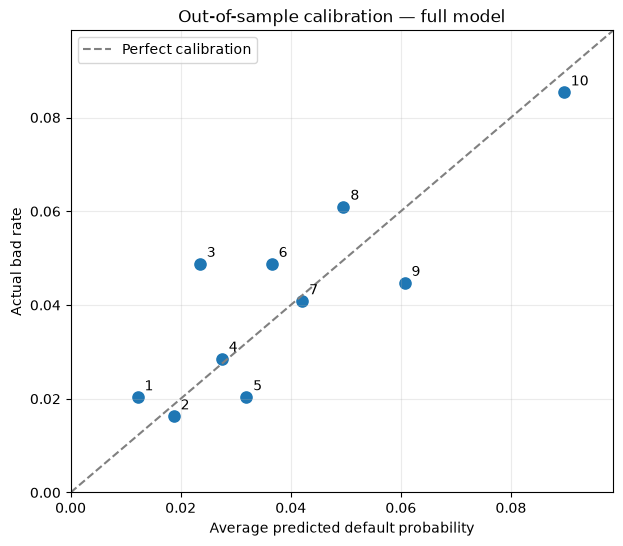

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

full_calibration_data = pd.DataFrame({
    "predicted_pd": np.asarray(
        predicted_probability_out, dtype=float
    ),
    "actual_bad": np.asarray(y_out, dtype=int),
})

if not np.isfinite(full_calibration_data["predicted_pd"]).all():
    raise ValueError("Predicted probabilities contain invalid values.")

# Divide accounts into ten groups by predicted default probability.
full_calibration_data["band"] = pd.qcut(
    full_calibration_data["predicted_pd"],
    q=10,
    duplicates="drop",
)

full_calibration_table = (
    full_calibration_data
    .groupby("band", observed=True)
    .agg(
        accounts=("actual_bad", "size"),
        actual_bads=("actual_bad", "sum"),
        average_predicted_pd=("predicted_pd", "mean"),
        actual_bad_rate=("actual_bad", "mean"),
        lowest_predicted_pd=("predicted_pd", "min"),
        highest_predicted_pd=("predicted_pd", "max"),
    )
    .reset_index(drop=True)
)

full_calibration_table.insert(
    0,
    "risk_band",
    range(1, len(full_calibration_table) + 1),
)

full_calibration_table["difference"] = (
    full_calibration_table["actual_bad_rate"]
    - full_calibration_table["average_predicted_pd"]
)

print("FULL-MODEL OUT-OF-SAMPLE CALIBRATION BY RISK BAND")
display(
    full_calibration_table.style.format({
        "average_predicted_pd": "{:.2%}",
        "actual_bad_rate": "{:.2%}",
        "lowest_predicted_pd": "{:.2%}",
        "highest_predicted_pd": "{:.2%}",
        "difference": "{:+.2%}",
    })
)

print(
    f"Overall average predicted PD: "
    f"{full_calibration_data['predicted_pd'].mean():.2%}"
)
print(
    f"Overall actual bad rate: "
    f"{full_calibration_data['actual_bad'].mean():.2%}"
)

# Plot observed versus predicted bad rates.
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    full_calibration_table["average_predicted_pd"],
    full_calibration_table["actual_bad_rate"],
    s=65,
)

for row in full_calibration_table.itertuples():
    ax.annotate(
        str(row.risk_band),
        (row.average_predicted_pd, row.actual_bad_rate),
        xytext=(5, 5),
        textcoords="offset points",
    )

upper_limit = max(
    full_calibration_table["average_predicted_pd"].max(),
    full_calibration_table["actual_bad_rate"].max(),
    0.01,
) * 1.1

ax.plot(
    [0, upper_limit],
    [0, upper_limit],
    linestyle="--",
    color="grey",
    label="Perfect calibration",
)

ax.set_xlim(0, upper_limit)
ax.set_ylim(0, upper_limit)
ax.set_xlabel("Average predicted default probability")
ax.set_ylabel("Actual bad rate")
ax.set_title("Out-of-sample calibration — full model")
ax.legend()
ax.grid(alpha=0.25)

plt.show()